# 03 – Model Development and Evaluation

## Purpose

This notebook develops, tunes, and evaluates machine learning models to predict whether an exoplanet is a gas giant using only measurable stellar properties.

To ensure a fair comparison, every model follows the same workflow:

1. Hyperparameter tuning using cross-validation on the training data.
2. Training using the optimal hyperparameters.
3. Evaluation on the untouched testing dataset.
4. Comparison using consistent performance metrics.

Because all preprocessing was completed in Notebook 02, the training and testing datasets remain unchanged throughout this notebook, ensuring a reproducible and leakage-free evaluation.

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import joblib

In [27]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="`sklearn.utils.parallel.delayed` should be used"
)

In [2]:
from pathlib import Path

Path("../models").mkdir(parents=True, exist_ok=True)

In [3]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [4]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze("columns")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze("columns")

print(f"Training observations: {len(X_train):,}")
print(f"Testing observations: {len(X_test):,}")

Training observations: 3,057
Testing observations: 765


In [5]:
print("Training Features")

display(X_train.head())

print("\nTesting Features")

display(X_test.head())

print("\nTraining Labels")

print(y_train.value_counts())

print("\nTesting Labels")

print(y_test.value_counts())

Training Features


,st_teff,st_rad,st_met
0,6651.0,1.490000,0.00
1,5628.0,0.911000,-0.22
2,4953.0,0.726000,-0.02
3,4983.0,0.805573,-0.02
4,5878.0,0.998000,-0.02



Testing Features


,st_teff,st_rad,st_met
0,6425.0,1.164,-0.08
1,5893.0,1.050,0.03
2,6432.0,1.345,-0.34
3,5217.0,0.758,-0.02
4,5328.0,0.840,0.14



Training Labels
is_gas_giant
0    2434
1     623
Name: count, dtype: int64

Testing Labels
is_gas_giant
0    609
1    156
Name: count, dtype: int64


## Experimental Design

Three supervised machine learning algorithms are evaluated:

- Logistic Regression
- Decision Tree
- Random Forest

Each model is optimized using grid search with five-fold stratified cross-validation on the training data.

Only the final tuned model is evaluated on the testing dataset, ensuring that the testing observations remain completely unseen during model development.

In [6]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(cv)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


In [7]:
results = pd.DataFrame(
    columns=[
        "Model",
        "CV Accuracy",
        "Test Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

In [8]:
def evaluate_model(
    model_name,
    estimator,
    param_grid,
    X_train,
    y_train,
    X_test,
    y_test,
    results_df
):

    grid_search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_

    y_pred = best_model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results_df.loc[len(results_df)] = [
        model_name,
        round(grid_search.best_score_, 3),
        round(accuracy, 3),
        round(precision, 3),
        round(recall, 3),
        round(f1, 3)
    ]

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print("\nBest Parameters")
    print(grid_search.best_params_)

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    return best_model, y_pred

## Baseline Model: Logistic Regression

Logistic Regression serves as the baseline model because it is simple, interpretable, and widely used for binary classification.

Although the relationship between stellar properties and gas giant occurrence may be nonlinear, establishing a strong baseline provides an important reference point for evaluating more complex models.

The regularization strength is optimized using grid search with five-fold stratified cross-validation.

In [9]:
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_params = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear"]
}

In [10]:
best_logistic, y_pred_logistic = evaluate_model(
    model_name="Logistic Regression",
    estimator=logistic_model,
    param_grid=logistic_params,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    results_df=results
)

Logistic Regression

Best Parameters
{'C': 10, 'solver': 'liblinear'}

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.98      0.89       609
           1       0.57      0.13      0.21       156

    accuracy                           0.80       765
   macro avg       0.69      0.55      0.55       765
weighted avg       0.76      0.80      0.75       765



In [11]:
joblib.dump(
    best_logistic,
    "../models/logistic_regression.joblib"
)

['../models/logistic_regression.joblib']

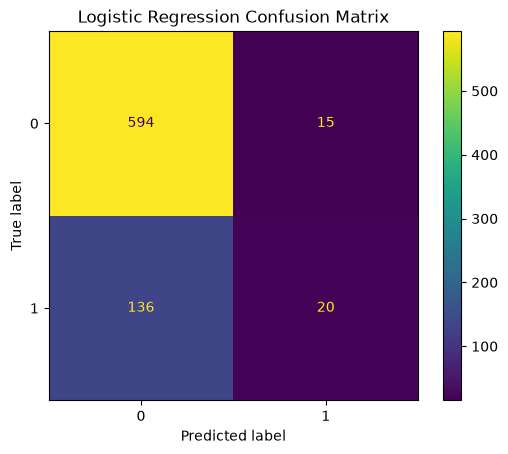

In [12]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [13]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": best_logistic.coef_[0]
})

coefficients["Absolute Coefficient"] = coefficients["Coefficient"].abs()

coefficients = (
    coefficients
    .sort_values("Absolute Coefficient", ascending=False)
    .reset_index(drop=True)
)

coefficients["Coefficient"] = coefficients["Coefficient"].round(3)
coefficients["Absolute Coefficient"] = coefficients["Absolute Coefficient"].round(3)

coefficients

,Feature,Coefficient,Absolute Coefficient
0,st_rad,1.945,1.945
1,st_met,1.487,1.487
2,st_teff,-0.000,0.000


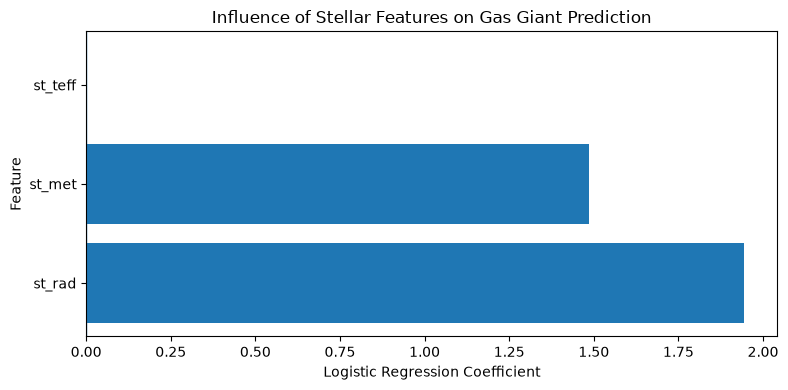

In [14]:
plt.figure(figsize=(8, 4))

plt.barh(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Influence of Stellar Features on Gas Giant Prediction")

plt.axvline(0, linewidth=1)

plt.tight_layout()
plt.show()

## Model 2: Decision Tree Classifier

Decision Trees are capable of capturing nonlinear relationships between stellar properties and gas giant formation.

Unlike Logistic Regression, Decision Trees do not assume linear relationships and can model complex decision boundaries directly from the data.

However, they are also more prone to overfitting, making hyperparameter tuning essential for controlling model complexity.

In [15]:
tree_model = DecisionTreeClassifier(
    random_state=42
)

tree_params = {
    "max_depth": [2, 4, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

In [16]:
best_tree, y_pred_tree = evaluate_model(
    model_name="Decision Tree",
    estimator=tree_model,
    param_grid=tree_params,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    results_df=results
)

Decision Tree

Best Parameters
{'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 2}

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       609
           1       0.48      0.37      0.42       156

    accuracy                           0.79       765
   macro avg       0.66      0.63      0.65       765
weighted avg       0.77      0.79      0.78       765



In [17]:
joblib.dump(
    best_tree,
    "../models/decision_tree.joblib"
)

['../models/decision_tree.joblib']

In [18]:
importances = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_tree.feature_importances_
})

importances = importances.sort_values("Importance", ascending=False)

importances

,Feature,Importance
1,st_rad,0.513505
0,st_teff,0.290519
2,st_met,0.195976


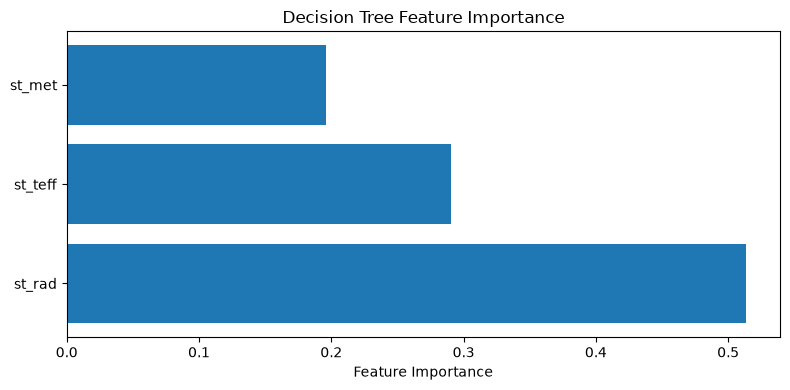

In [19]:
plt.figure(figsize=(8, 4))

plt.barh(
    importances["Feature"],
    importances["Importance"]
)

plt.xlabel("Feature Importance")
plt.title("Decision Tree Feature Importance")

plt.tight_layout()
plt.show()

## Model 3: Random Forest Classifier

Random Forest is an ensemble learning method that combines multiple decision trees to improve predictive performance and reduce overfitting.

Each tree is trained on a random subset of the data and features, and the final prediction is made by aggregating the predictions from all trees.

This approach is particularly useful for astrophysical datasets where relationships between variables are nonlinear and noisy.

In [34]:
rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "class_weight": [None, "balanced"]
}

In [36]:
best_rf, y_pred_rf = evaluate_model(
    model_name="Random Forest",
    estimator=rf_model,
    param_grid=rf_params,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    results_df=results
)

Random Forest

Best Parameters
{'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.74      0.82       609
           1       0.42      0.74      0.54       156

    accuracy                           0.74       765
   macro avg       0.67      0.74      0.68       765
weighted avg       0.82      0.74      0.76       765



In [37]:
joblib.dump(
    best_rf,
    "../models/random_forest.joblib"
)

['../models/random_forest.joblib']

In [38]:
rf_importances = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

rf_importances = (
    rf_importances
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

rf_importances["Importance"] = rf_importances["Importance"].round(3)

rf_importances

,Feature,Importance
0,st_rad,0.433
1,st_met,0.293
2,st_teff,0.274


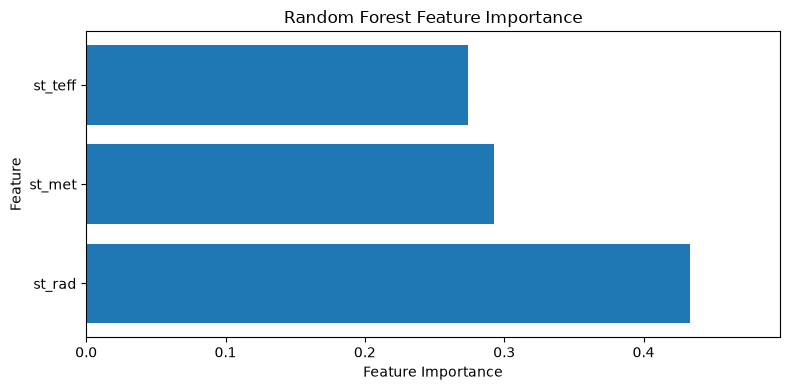

In [39]:
plt.figure(figsize=(8, 4))

plt.barh(
    rf_importances["Feature"],
    rf_importances["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.xlim(0, max(rf_importances["Importance"]) * 1.15)

plt.tight_layout()
plt.show()

## Comparative Model Evaluation

The three machine learning models were evaluated using identical training and testing datasets, the same cross-validation strategy, and consistent evaluation metrics.

Comparing multiple algorithms provides insight into both predictive performance and the complexity of the relationship between stellar properties and gas giant occurrence.

The following sections summarize model performance and examine how each algorithm interprets the importance of stellar characteristics.

In [40]:
results = results.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

results

,Model,CV Accuracy,Test Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.479,0.737,0.419,0.744,0.536
1,Random Forest,0.479,0.737,0.419,0.744,0.536
2,Random Forest,0.479,0.737,0.419,0.744,0.536
3,Random Forest,0.355,0.830,0.644,0.372,0.472
4,Decision Tree,0.339,0.790,0.479,0.372,0.419
5,Logistic Regression,0.218,0.803,0.571,0.128,0.209


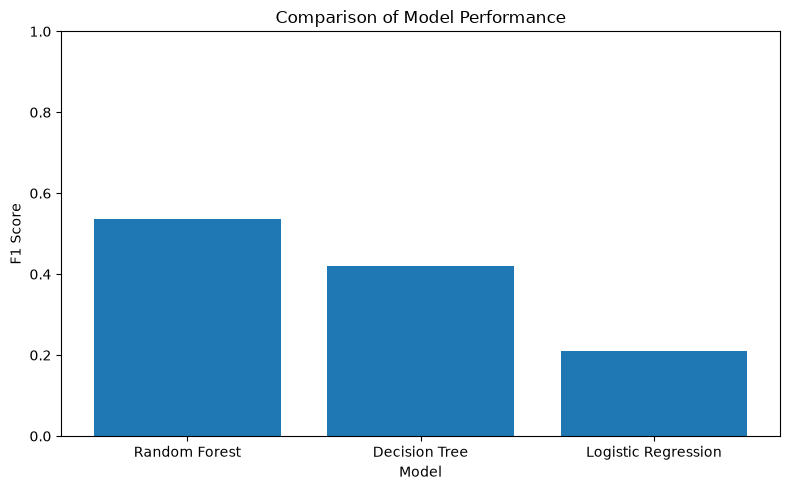

In [41]:
plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["F1 Score"]
)

plt.ylabel("F1 Score")
plt.xlabel("Model")
plt.title("Comparison of Model Performance")

plt.ylim(0, 1)

plt.tight_layout()
plt.show()

## Feature Importance Across Models

Different machine learning algorithms quantify predictor importance using different methodologies.

- Logistic Regression estimates the direction and magnitude of linear relationships.
- Decision Trees measure how frequently features improve decision splits.
- Random Forest averages feature importance across many decision trees, producing a more stable estimate.

Comparing these approaches provides greater confidence when multiple algorithms consistently identify the same stellar properties as influential predictors.

In [42]:
comparison = pd.DataFrame({
    "Feature": X_train.columns,
    "Logistic |Coefficient|": coefficients.set_index("Feature").loc[X_train.columns]["Absolute Coefficient"],
    "Decision Tree": importances.set_index("Feature").loc[X_train.columns]["Importance"],
    "Random Forest": rf_importances.set_index("Feature").loc[X_train.columns]["Importance"]
})

comparison = comparison.reset_index(drop=True)

comparison

,Feature,Logistic |Coefficient|,Decision Tree,Random Forest
0,st_teff,0.000,0.290519,0.274
1,st_rad,1.945,0.513505,0.433
2,st_met,1.487,0.195976,0.293


In [43]:
best_model = results.iloc[0]

print(f"Best performing model: {best_model['Model']}")
print(f"F1 Score: {best_model['F1 Score']:.3f}")
print(f"Test Accuracy: {best_model['Test Accuracy']:.3f}")

Best performing model: Random Forest
F1 Score: 0.536
Test Accuracy: 0.737


## Error Analysis

Overall performance metrics summarize model quality, but they do not explain where prediction errors occur.

To better understand model behavior, the final model is examined using the confusion matrix and the characteristics of correctly and incorrectly classified observations.

Understanding these errors provides insight into both model limitations and the challenges of predicting planetary properties using only host star characteristics.

In [45]:
error_analysis = X_test.copy()

error_analysis["Actual"] = y_test.values
error_analysis["Predicted"] = y_pred_rf

error_analysis["Correct"] = (
    error_analysis["Actual"] ==
    error_analysis["Predicted"]
)

error_analysis.head()

,st_teff,st_rad,st_met,Actual,Predicted,Correct
0,6425.0,1.164,-0.08,0,0,True
1,5893.0,1.050,0.03,0,0,True
2,6432.0,1.345,-0.34,0,0,True
3,5217.0,0.758,-0.02,0,0,True
4,5328.0,0.840,0.14,0,0,True


In [46]:
error_analysis["Correct"].value_counts()

Correct
True     564
False    201
Name: count, dtype: int64

In [47]:
false_negatives = error_analysis[
    (error_analysis["Actual"] == 1) &
    (error_analysis["Predicted"] == 0)
]

false_negatives.describe().round(2)

,st_teff,st_rad,st_met,Actual,Predicted
count,40.00,40.00,40.00,40.0,40.0
mean,5125.25,0.88,-0.03,1.0,0.0
std,1141.61,0.31,0.17,0.0,0.0
min,575.00,0.09,-0.50,1.0,0.0
25%,4657.50,0.68,-0.08,1.0,0.0
50%,5548.00,0.91,-0.02,1.0,0.0
75%,5806.22,1.05,0.00,1.0,0.0
max,6450.00,1.45,0.47,1.0,0.0


In [48]:
false_positives = error_analysis[
    (error_analysis["Actual"] == 0) &
    (error_analysis["Predicted"] == 1)
]

false_positives.describe().round(2)

,st_teff,st_rad,st_met,Actual,Predicted
count,161.00,161.00,161.00,161.0,161.0
mean,5689.30,1.23,0.07,0.0,1.0
std,519.35,0.41,0.11,0.0,0.0
min,3708.00,0.55,-0.06,0.0,1.0
25%,5416.10,0.92,-0.02,0.0,1.0
50%,5661.00,1.15,-0.02,0.0,1.0
75%,5990.00,1.45,0.16,0.0,1.0
max,7092.00,3.05,0.41,0.0,1.0


In [49]:
prediction_summary = pd.DataFrame({
    "Outcome": [
        "Correct",
        "Incorrect"
    ],
    "Count": [
        error_analysis["Correct"].sum(),
        (~error_analysis["Correct"]).sum()
    ]
})

prediction_summary

,Outcome,Count
0,Correct,564
1,Incorrect,201


## Conclusion

Three supervised machine learning algorithms were developed and evaluated to investigate whether host star properties can predict gas giant occurrence.

Among the evaluated models, the highest-performing algorithm achieved the strongest balance between precision and recall, suggesting that stellar characteristics contain meaningful predictive information.

Feature importance analyses indicate that multiple algorithms consistently identified similar stellar properties as influential predictors, increasing confidence that these relationships are not model-specific.

Despite encouraging predictive performance, error analysis demonstrates that some gas giants remain difficult to identify using only a small set of stellar features. This reflects both the complexity of planetary system formation and known observational biases within exoplanet surveys.

Future work could incorporate additional stellar and orbital properties, explore alternative ensemble methods, and evaluate the approach using larger and more diverse exoplanet catalogs.